## Import packages

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import spearmanr

## Load all JSON files

In [27]:
import json
import glob
import os
import pandas as pd

rows = []

for filepath in sorted(glob.glob("llm_raw/iteration_*.json")):
    filename = os.path.basename(filepath)
    iteration = int(filename.split("_")[1].split(".")[0])  # e.g. iteration_03.json -> 3

    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    for item in data:
        irony = item.get("irony", {})

        rows.append({
            "iteration": iteration,
            "comment_id": item["id"],
            "thread": item["thread_title"],
            "comment": item["comment"],
            "irony_score": int(irony.get("irony_score")),
            "confidence_score": int(irony.get("confidence_score")),
            "justification": irony.get("justification"),
            "irony_markers": irony.get("irony_markers", [])
        })

llm_long_df = pd.DataFrame(rows)
llm_long_df.head()

,iteration,comment_id,thread,comment,irony_score,confidence_score,justification,irony_markers
0,1,1,Mehrheit sieht ältere im Vorteil – nicht einma...,Solange alle ihre Tiefkühlpizza und RTL haben ...,4,4,Die wörtliche Behauptung 'Solange alle ihre Ti...,"[sarcasm, critiques media/consumerism, hyperbo..."
1,1,2,Mehrheit sieht ältere im Vorteil – nicht einma...,Ich bin schockiert.,1,4,The comment 'Ich bin schockiert.' is a direct ...,"[literal expression of emotion, no explicit ir..."
2,1,3,Mehrheit sieht ältere im Vorteil – nicht einma...,"Würden sich die babyboomer zu Tode arbeiten, b...",4,4,"The comment uses a hyperbolic, sarcastic state...","[sarcasm, hyperbole, ageism]"
3,1,4,Mehrheit sieht ältere im Vorteil – nicht einma...,Auf den Schreck erstmal eine Rentenerhöhung.,4,4,The comment leverages the idiom 'Auf den Schre...,"[idiom: Auf den Schreck, sarcastic/political c..."
4,1,5,Mehrheit sieht ältere im Vorteil – nicht einma...,Finde den Generationen-Vertrag an sich schon d...,1,4,The comment expresses a literal opinion that t...,[no irony markers detected; literal stance]


In [28]:
llm_long_df.shape

(240, 8)

In [29]:
llm_comment_stats_df = (
    llm_long_df
    .groupby(["comment_id", "thread", "comment"], as_index=False)
    .agg(
        mean_irony=("irony_score", "mean"),
        var_irony=("irony_score", "var"),
        std_irony=("irony_score", "std"),
        mean_confidence=("confidence_score", "mean"),
        var_confidence=("confidence_score", "var"),
        std_confidence=("confidence_score", "std"),
    )
    .sort_values("comment_id")
    .reset_index(drop=True)
)

llm_comment_stats_df.head()

,comment_id,thread,comment,mean_irony,var_irony,std_irony,mean_confidence,var_confidence,std_confidence
0,1,Mehrheit sieht ältere im Vorteil – nicht einma...,Solange alle ihre Tiefkühlpizza und RTL haben ...,4.00,0.00,0.0,4.00,0.00,0.0
1,2,Mehrheit sieht ältere im Vorteil – nicht einma...,Ich bin schockiert.,1.00,0.00,0.0,4.25,0.25,0.5
2,3,Mehrheit sieht ältere im Vorteil – nicht einma...,"Würden sich die babyboomer zu Tode arbeiten, b...",4.25,0.25,0.5,4.00,0.00,0.0
3,4,Mehrheit sieht ältere im Vorteil – nicht einma...,Auf den Schreck erstmal eine Rentenerhöhung.,3.75,0.25,0.5,4.00,0.00,0.0
4,5,Mehrheit sieht ältere im Vorteil – nicht einma...,Finde den Generationen-Vertrag an sich schon d...,1.00,0.00,0.0,4.00,0.00,0.0


In [30]:
print(llm_comment_stats_df.shape)
print(llm_comment_stats_df.columns)

(60, 9)
Index(['comment_id', 'thread', 'comment', 'mean_irony', 'var_irony',
       'std_irony', 'mean_confidence', 'var_confidence', 'std_confidence'],
      dtype='str')


In [31]:
display(llm_comment_stats_df[llm_comment_stats_df["comment_id"] == 33])

,comment_id,thread,comment,mean_irony,var_irony,std_irony,mean_confidence,var_confidence,std_confidence
32,33,VW gerettet! Konzern feuert alle Arbeiter und ...,"Unironisch könnte man viele Konzerne retten, w...",2.75,4.25,2.061553,4.25,0.25,0.5


## Visualisations

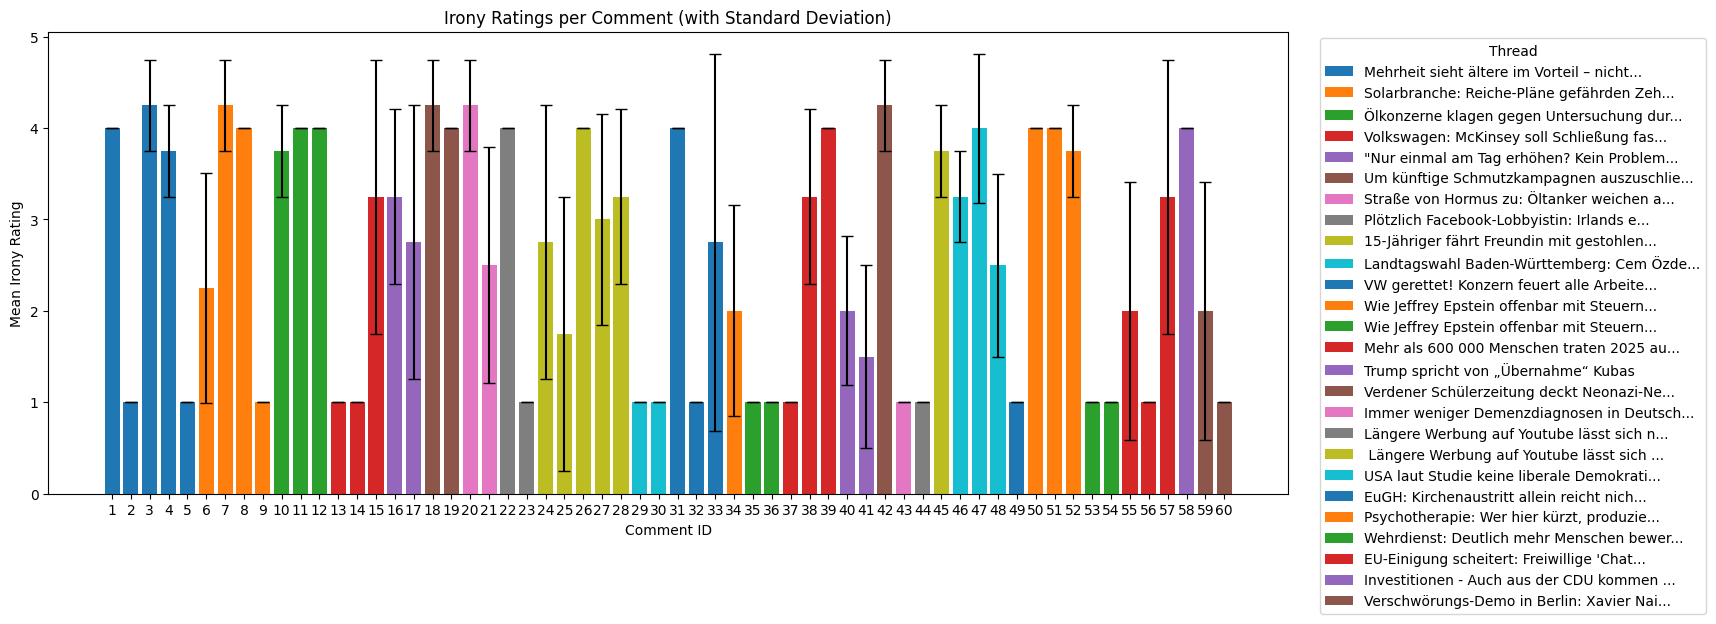

In [32]:
# Create numeric x positions
x = range(len(llm_comment_stats_df))

# Use simple IDs for x-axis
labels = llm_comment_stats_df["comment_id"]

# Assign colors per thread
threads = llm_comment_stats_df["thread"].unique()
cmap = plt.get_cmap("tab10")
thread_colors = {thread: cmap(i % 10) for i, thread in enumerate(threads)}

colors = llm_comment_stats_df["thread"].map(thread_colors)

plt.figure(figsize=(16, 6))

# Bar plot with error bars (standard deviation)
plt.bar(
    x,
    llm_comment_stats_df["mean_irony"],
    yerr=llm_comment_stats_df["std_irony"],
    capsize=4,
    color=colors
)

# Clean x-axis
plt.xticks(x, labels, rotation=0)
plt.xlabel("Comment ID")
plt.ylabel("Mean Irony Rating")
plt.title("Irony Ratings per Comment (with Standard Deviation)")

# Legend for threads
legend_elements = [
    Patch(facecolor=thread_colors[t], label=t[:40] + "..." if len(t) > 40 else t)
    for t in threads
]

plt.legend(
    handles=legend_elements,
    title="Thread",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.show()

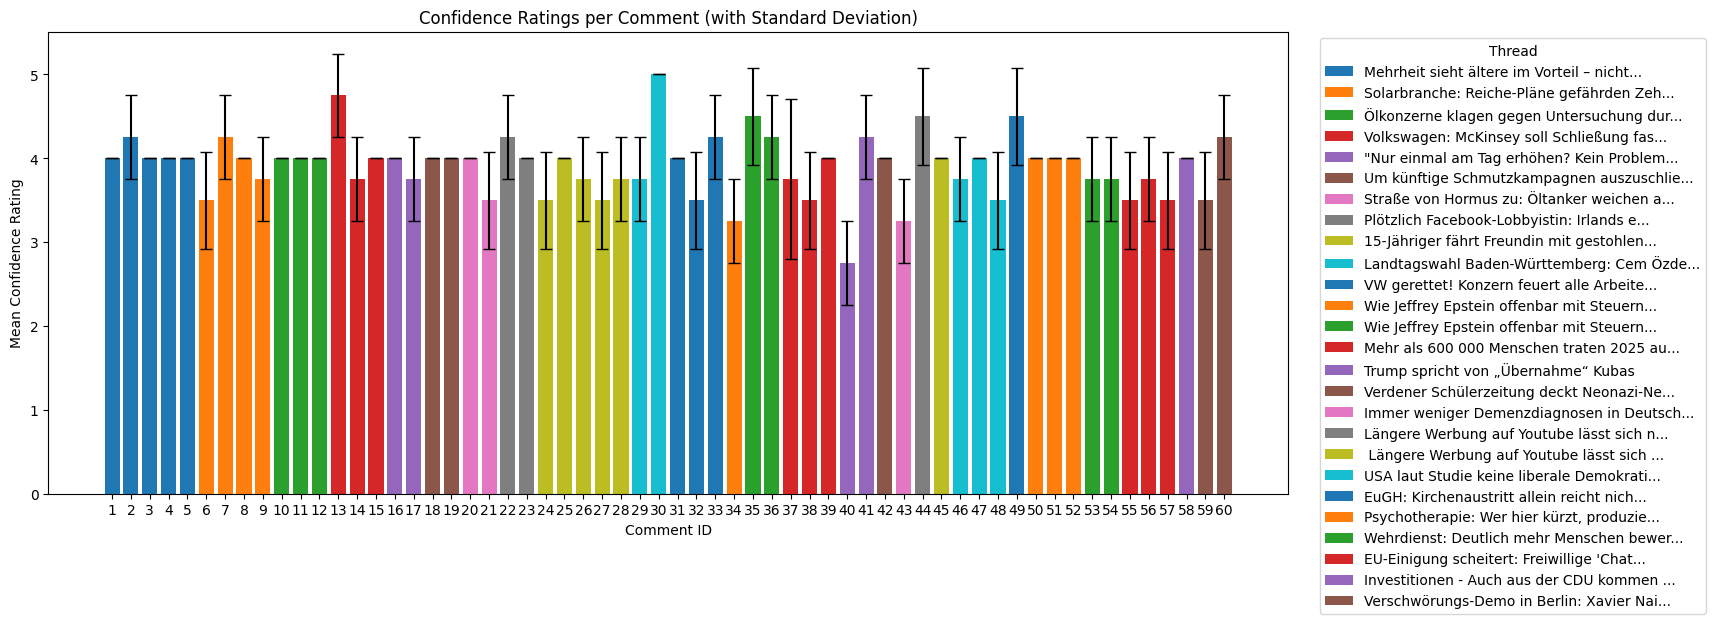

In [33]:
# Create numeric x positions
x = range(len(llm_comment_stats_df))

# Use simple IDs for x-axis
labels = llm_comment_stats_df["comment_id"]

# Assign colors per thread
threads = llm_comment_stats_df["thread"].unique()
cmap = plt.get_cmap("tab10")
thread_colors = {thread: cmap(i % 10) for i, thread in enumerate(threads)}

colors = llm_comment_stats_df["thread"].map(thread_colors)

plt.figure(figsize=(16, 6))

# Bar plot with error bars (standard deviation)
plt.bar(
    x,
    llm_comment_stats_df["mean_confidence"],
    yerr=llm_comment_stats_df["std_confidence"],
    capsize=4,
    color=colors
)

# Clean x-axis
plt.xticks(x, labels, rotation=0)
plt.xlabel("Comment ID")
plt.ylabel("Mean Confidence Rating")
plt.title("Confidence Ratings per Comment (with Standard Deviation)")

# Legend for threads
legend_elements = [
    Patch(facecolor=thread_colors[t], label=t[:40] + "..." if len(t) > 40 else t)
    for t in threads
]

plt.legend(
    handles=legend_elements,
    title="Thread",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.show()

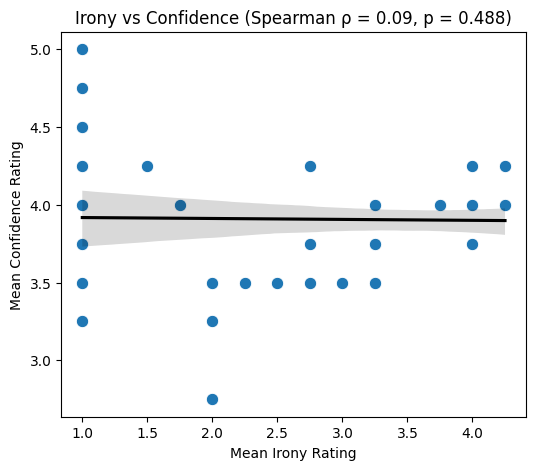

In [34]:
# Compute correlation (just to show it in the plot)
# rho: strength of correlation
# p: significance of the correlation
rho, p = spearmanr(
    llm_comment_stats_df["mean_irony"],
    llm_comment_stats_df["mean_confidence"]
)

plt.figure(figsize=(6, 5))

# Scatter plot
sns.scatterplot(
    data=llm_comment_stats_df,
    x="mean_irony",
    y="mean_confidence",
    s=80
)

# Regression line
sns.regplot(
    data=llm_comment_stats_df,
    x="mean_irony",
    y="mean_confidence",
    scatter=False,
    color="black"
)

# Labels
plt.xlabel("Mean Irony Rating")
plt.ylabel("Mean Confidence Rating")
plt.title(f"Irony vs Confidence (Spearman ρ = {rho:.2f}, p = {p:.3f})")

plt.show()